# Avance 2: Modelo Relacional de Ventas TechCore

**Proyecto:** DataVision Analytics - TechCore  
**Objetivo:** Diseñar e implementar el modelo relacional que permitirá integrar la información de ventas con las demás entidades del negocio (productos, clientes, sucursales y vendedores), asegurando coherencia, integridad y trazabilidad de los datos.

**Dataset:** ventasTransformed.csv (exportado desde Power Query en Avance 1)

---

## Tabla de Contenido

1. Carga de Datos y Configuración Inicial
2. Exploración de Datos del Dataset Limpio
3. Creación de Tablas Dimensionales (Clientes, Ciudades, Sucursales, Vendedores, Productos)
4. Creación de Tablas de Hechos (Facturas, DetalleFacturas)
5. Validación de Integridad Referencial
6. Reportes Exploratorios
7. Exportación del Modelo a Excel
8. Implementación Opcional con SQLite
9. Diagrama Entidad-Relación del Modelo

## 1. Carga de Datos y Configuración Inicial

Importamos las librerías necesarias para el análisis y construcción del modelo relacional.

In [50]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("Librerías importadas correctamente")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")

Librerías importadas correctamente
Versión de pandas: 2.3.2
Versión de numpy: 2.2.6


### Cargar el dataset limpio exportado desde Power Query

In [51]:
# Cargar el dataset transformado
df_ventas = pd.read_csv('ventasTransformed.csv', encoding='utf-8')

print(f"Dataset cargado exitosamente")
print(f"Dimensiones: {df_ventas.shape[0]:,} filas x {df_ventas.shape[1]} columnas")
print(f"\nPrimeras 3 filas:")
df_ventas.head(3)

Dataset cargado exitosamente
Dimensiones: 30,000 filas x 33 columnas

Primeras 3 filas:


,Ciudad,DireccionCliente,EmailCliente,Año,Trimestre,Mes,Día,GeneroCliente,MarcaProducto1,HoraVenta,MarcaProducto2,MarcaProducto3,MetodoPago,NombreProducto1,NombreProducto2,NombreProducto3,SucursalNormalizada,TelefonoCliente,VendedorNombre,CantidadProducto1,CantidadProducto2,CantidadProducto3,DescuentoVenta(%),EdadCliente,PrecioUnitarioProducto1,PrecioUnitarioProducto2,PrecioUnitarioProducto3,SubtotalProducto1,SubtotalProducto2,SubtotalProducto3,TotalVenta,VentaID,ClienteNombre
0,Bogotá,cll 1 #16-16,alberto95@yahoo.com,2020,Qtr 3,julio,15,M,HP,1899-12-30 10:08:00,Dell,Sin Venta,Tarjeta Débito,HP Envy 13,Dell Latitude 7420,Sin Venta,TechCore Bogotá #2,'+34803219872,Edu Juan Pedraza,1,20,0,5,33,4000000,56000000,0,4000000,112000000,0,144400000,18789,Alberto Arranz Cepeda
1,Bogotá,cll 1 #17-12,albino50@gmail.com,2018,Qtr 1,febrero,19,M,Dell,1899-12-30 06:56:02,Dell,Sin Venta,Efectivo,Dell XPS 13,Dell Inspiron 15,Sin Venta,TechCore Bogotá #2,'+34963623818,Eloísa Plaza Hurtado,1,10,0,0,27,4800000,30000000,0,4800000,30000000,0,78000000,362,Albino Nieto Reguera
2,Bogotá,cll 1 #23-16,ámbar54@gmail.com,2017,Qtr 4,noviembre,27,F,MSI,1899-12-30 01:46:12,Dell,Sin Venta,Transferencia,MSI Modern 14,Dell XPS 13,Sin Venta,TechCore Bogotá #2,'+34845754806,Herminia Meléndez Huguet,2,20,0,0,21,2800000,48000000,0,5600000,96000000,0,152000000,22278,Ámbar Valls Exposito


### Corregir la columna Fecha (problema identificado)

In [52]:
# Corregir la columna Fecha - Mapear meses a números y crear fecha válida
meses_map = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12,
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4, 'Mayo': 5, 'Junio': 6,
    'Julio': 7, 'Agosto': 8, 'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

df_ventas['Mes_Numero'] = df_ventas['Mes'].map(meses_map)
df_ventas['Fecha_Corregida'] = pd.to_datetime(
    df_ventas[['Año', 'Mes_Numero', 'Día']].fillna(0).astype(int).apply(
        lambda x: f"{int(x['Año']):04d}-{int(x['Mes_Numero']):02d}-{int(x['Día']):02d}", axis=1
    ),
    format='%Y-%m-%d',
    errors='coerce'
)

print("Corrección de fechas aplicada:")
print(f"Nulos en Fecha_Corregida: {df_ventas['Fecha_Corregida'].isnull().sum()}")
print("Primeras 5 fechas corregidas:")
print(df_ventas[['Año', 'Mes', 'Día', 'Fecha_Corregida']].head())

Corrección de fechas aplicada:
Nulos en Fecha_Corregida: 0
Primeras 5 fechas corregidas:
    Año        Mes  Día Fecha_Corregida
0  2020      julio   15      2020-07-15
1  2018    febrero   19      2018-02-19
2  2017  noviembre   27      2017-11-27
3  2021      abril    9      2021-04-09
4  2018       mayo    5      2018-05-05


## 2. Exploración de Datos del Dataset Limpio

Analizamos la estructura del dataset para identificar las entidades y sus relaciones.

In [53]:
# Exploración general del dataset
print("Información del Dataset:")
print("="*80)
print(df_ventas.info())
print("\n" + "="*80)
print("\nColumnas disponibles:")
print(df_ventas.columns.tolist())
print("\n" + "="*80)
print("\nValores nulos por columna:")
print(df_ventas.isnull().sum())

Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Ciudad                   30000 non-null  object        
 1   DireccionCliente         30000 non-null  object        
 2   EmailCliente             30000 non-null  object        
 3   Año                      30000 non-null  int64         
 4   Trimestre                30000 non-null  object        
 5   Mes                      30000 non-null  object        
 6   Día                      30000 non-null  int64         
 7   GeneroCliente            30000 non-null  object        
 8   MarcaProducto1           30000 non-null  object        
 9   HoraVenta                30000 non-null  object        
 10  MarcaProducto2           30000 non-null  object        
 11  MarcaProducto3           30000 non-null  object        
 12  MetodoP

## 3. Creación de Tablas Dimensionales

### 3.1 Tabla Ciudades

**Atributos:** CiudadID (PK), NombreCiudad  
**Descripción:** Catálogo de ciudades donde operan las sucursales de TechCore.

In [54]:
# Crear tabla Ciudades
ciudades_unicas = df_ventas['Ciudad'].dropna().unique()
tabla_ciudades = pd.DataFrame({
    'CiudadID': range(1, len(ciudades_unicas) + 1),
    'NombreCiudad': sorted(ciudades_unicas)
})

print(f"Tabla Ciudades creada: {len(tabla_ciudades)} registros")
print(f"\nPrimeros 5 registros:")
print(tabla_ciudades.head())
print(f"\nCiudades: {', '.join(tabla_ciudades['NombreCiudad'].tolist())}")

Tabla Ciudades creada: 4 registros

Primeros 5 registros:
   CiudadID NombreCiudad
0         1       Bogotá
1         2         Cali
2         3     Medellín
3         4      Pereira

Ciudades: Bogotá, Cali, Medellín, Pereira


### 3.2 Tabla Sucursales

**Atributos:** SucursalID (PK), NombreSucursal, CiudadID (FK)  
**Relación:** Muchas sucursales → Una ciudad (N:1)  
**Descripción:** Puntos de venta de TechCore en diferentes ciudades.

In [55]:
# Crear tabla Sucursales
sucursales_data = df_ventas[['SucursalNormalizada', 'Ciudad']].drop_duplicates().reset_index(drop=True)

# Crear diccionario de mapeo Ciudad -> CiudadID
ciudad_to_id = dict(zip(tabla_ciudades['NombreCiudad'], tabla_ciudades['CiudadID']))

# Crear tabla con CiudadID como FK
tabla_sucursales = pd.DataFrame({
    'SucursalID': range(1, len(sucursales_data) + 1),
    'NombreSucursal': sucursales_data['SucursalNormalizada'].values,
    'CiudadID': sucursales_data['Ciudad'].map(ciudad_to_id).values
})

print(f"Tabla Sucursales creada: {len(tabla_sucursales)} registros")
print(f"\nPrimeras 10 sucursales:")
tabla_sucursales.head(10)

Tabla Sucursales creada: 6 registros

Primeras 10 sucursales:


,SucursalID,NombreSucursal,CiudadID
0,1,TechCore Bogotá #2,1
1,2,TechCore Bogotá #1,1
2,3,TechCore Cali,2
3,4,TechCore Medellín #2,3
4,5,TechCore Medellín #1,3
5,6,TechCore Pereira,4


### 3.3 Tabla Vendedores

**Atributos:** VendedorID (PK), NombreVendedor  
**Descripción:** Personal de ventas de TechCore.

In [56]:
# Crear tabla Vendedores
vendedores_unicos = df_ventas['VendedorNombre'].dropna().unique()
tabla_vendedores = pd.DataFrame({
    'VendedorID': range(1, len(vendedores_unicos) + 1),
    'NombreVendedor': sorted(vendedores_unicos)
})

print(f"Tabla Vendedores creada: {len(tabla_vendedores)} registros")
print(f"\nPrimeros 10 vendedores:")
tabla_vendedores.head(10)

Tabla Vendedores creada: 30 registros

Primeros 10 vendedores:


,VendedorID,NombreVendedor
0,1,Almudena Adelaida Lledó Garrido
1,2,Amílcar Ortega Alberto
2,3,Ana Sofía Llopis Blázquez
3,4,Anacleto Morera Segovia
4,5,Armida Azorin Plaza
5,6,Aura del Bermúdez
6,7,Basilio Marcos Barrena
7,8,Carina Parejo Carranza
8,9,Claudia Sastre Quintero
9,10,Clímaco Salinas Zabaleta


### 3.4 Tabla Clientes

**Atributos:** ClienteID (PK), NombreCliente, Género, Edad, Teléfono, Email, Dirección  
**Descripción:** Clientes que realizan compras en TechCore.

In [57]:
# Crear tabla Clientes
clientes_data = df_ventas[['ClienteNombre', 'GeneroCliente', 'EdadCliente', 
                             'TelefonoCliente', 'EmailCliente', 'DireccionCliente']].drop_duplicates().reset_index(drop=True)

tabla_clientes = pd.DataFrame({
    'ClienteID': range(1, len(clientes_data) + 1),
    'NombreCliente': clientes_data['ClienteNombre'].values,
    'Genero': clientes_data['GeneroCliente'].values,
    'Edad': clientes_data['EdadCliente'].values,
    'Telefono': clientes_data['TelefonoCliente'].values,
    'Email': clientes_data['EmailCliente'].values,
    'Direccion': clientes_data['DireccionCliente'].values
})

print(f"Tabla Clientes creada: {len(tabla_clientes)} registros")
print(f"\nPrimeros 5 clientes:")
tabla_clientes.head()

Tabla Clientes creada: 17453 registros

Primeros 5 clientes:


,ClienteID,NombreCliente,Genero,Edad,Telefono,Email,Direccion
0,1,Alberto Arranz Cepeda,M,33,'+34803219872,alberto95@yahoo.com,cll 1 #16-16
1,2,Albino Nieto Reguera,M,27,'+34963623818,albino50@gmail.com,cll 1 #17-12
2,3,Ámbar Valls Exposito,F,21,'+34845754806,ámbar54@gmail.com,cll 1 #23-16
3,4,Xiomara María Carmen Iniesta Palacios,F,32,'+34845393676,xiomara36@gmail.com,cll 1 #23-28
4,5,Noelia Aragón Olivera,F,29,'+34882780517,noelia89@hotmail.com,cll 1 #23-74


### 3.5 Tabla Productos

**Atributos:** ProductoID (PK), NombreProducto, Marca, PrecioUnitario  
**Descripción:** Catálogo de productos disponibles en TechCore.

**Nota:** Debido a que el dataset tiene 3 productos por venta, consolidaremos todos los productos únicos.

In [58]:
# Consolidar productos de las 3 columnas de productos
productos_list = []

for i in range(1, 4):
    prod_data = df_ventas[[f'NombreProducto{i}', f'MarcaProducto{i}', f'PrecioUnitarioProducto{i}']].dropna(subset=[f'NombreProducto{i}'])
    prod_data = prod_data[prod_data[f'NombreProducto{i}'] != 'Sin Venta']
    prod_data.columns = ['NombreProducto', 'Marca', 'PrecioUnitario']
    productos_list.append(prod_data)

# Concatenar y eliminar duplicados
productos_consolidados = pd.concat(productos_list, ignore_index=True)
productos_consolidados = productos_consolidados.drop_duplicates(subset=['NombreProducto', 'Marca']).reset_index(drop=True)

# Crear tabla Productos
tabla_productos = pd.DataFrame({
    'ProductoID': range(1, len(productos_consolidados) + 1),
    'NombreProducto': productos_consolidados['NombreProducto'].values,
    'Marca': productos_consolidados['Marca'].values,
    'PrecioUnitario': productos_consolidados['PrecioUnitario'].values
})

print(f"Tabla Productos creada: {len(tabla_productos)} registros")
print(f"\nPrimeros 10 productos:")
tabla_productos.head(10)

Tabla Productos creada: 44 registros

Primeros 10 productos:


,ProductoID,NombreProducto,Marca,PrecioUnitario
0,1,HP Envy 13,HP,4000000
1,2,Dell XPS 13,Dell,4800000
2,3,MSI Modern 14,MSI,2800000
3,4,Dell Inspiron 15,Dell,3000000
4,5,Lenovo Legion 5 Pro,Lenovo,7200000
5,6,Apple iMac 24,Apple,6400000
6,7,Lenovo Yoga 7i,Lenovo,4400000
7,8,Acer Nitro 5,Acer,4000000
8,9,HP Pavilion 15,HP,3500000
9,10,HP Spectre x360,HP,5200000


## 4. Creación de Tablas de Hechos

### 4.1 Tabla Facturas

**Atributos:** FacturaID (PK), Fecha, Año, Trimestre, Mes, Día, HoraVenta, SucursalID (FK), ClienteID (FK), VendedorID (FK), CalendarioID (FK), MetodoPago, TotalVenta  
**Descripción:** Registro de cada transacción de venta realizada en TechCore.

In [59]:
# Crear diccionarios de mapeo para FK
sucursal_to_id = dict(zip(tabla_sucursales['NombreSucursal'], tabla_sucursales['SucursalID']))
vendedor_to_id = dict(zip(tabla_vendedores['NombreVendedor'], tabla_vendedores['VendedorID']))

# Para clientes, usar combinación de nombre y email como clave única
cliente_key = tabla_clientes['NombreCliente'] + '|' + tabla_clientes['Email']
cliente_to_id = dict(zip(cliente_key, tabla_clientes['ClienteID']))

# Crear clave en df_ventas
df_ventas['ClienteKey'] = df_ventas['ClienteNombre'] + '|' + df_ventas['EmailCliente']

# Crear tabla Facturas
tabla_facturas = pd.DataFrame({
    'FacturaID': df_ventas['VentaID'].values,
    'Fecha': df_ventas['Fecha_Corregida'].values,  # Usar fecha corregida
    'Año': df_ventas['Año'].values,
    'Trimestre': df_ventas['Trimestre'].values,
    'Mes': df_ventas['Mes'].values,
    'Dia': df_ventas['Día'].values,
    'HoraVenta': df_ventas['HoraVenta'].values,
    'SucursalID': df_ventas['SucursalNormalizada'].map(sucursal_to_id).values,
    'ClienteID': df_ventas['ClienteKey'].map(cliente_to_id).values,
    'VendedorID': df_ventas['VendedorNombre'].map(vendedor_to_id).values,
    'MetodoPago': df_ventas['MetodoPago'].values,
    'TotalVenta': df_ventas['TotalVenta'].values
})

print(f"Tabla Facturas creada: {len(tabla_facturas)} registros")
print(f"\nPrimeras 5 facturas:")
tabla_facturas.head()

Tabla Facturas creada: 30000 registros

Primeras 5 facturas:


Primeras 5 facturas:


,FacturaID,Fecha,Año,Trimestre,Mes,Dia,HoraVenta,SucursalID,ClienteID,VendedorID,MetodoPago,TotalVenta
0,18789,2020-07-15,2020,Qtr 3,julio,15,1899-12-30 10:08:00,1,1,12,Tarjeta Débito,144400000
1,362,2018-02-19,2018,Qtr 1,febrero,19,1899-12-30 06:56:02,1,2,13,Efectivo,78000000
2,22278,2017-11-27,2017,Qtr 4,noviembre,27,1899-12-30 01:46:12,1,3,18,Transferencia,152000000
3,3280,2021-04-09,2021,Qtr 2,abril,9,1899-12-30 19:40:57,1,4,28,Billetera Digital,221400000
4,27908,2018-05-05,2018,Qtr 2,mayo,5,1899-12-30 22:50:53,2,5,15,Transferencia,268000000


### 4.3 Tabla Calendario

**Atributos:** CalendarioID (PK), Date, Año, Trimestre, Mes, MesNum, Día, AñoMes, NombreMes  
**Descripción:** Dimensión de tiempo para análisis temporal. Contiene todas las fechas desde 2017 hasta 2024. Usa CalendarioID como clave primaria para facilitar las relaciones en Power BI.

In [60]:
# Crear tabla Calendario (Dimensión de Tiempo)
import pandas as pd

# Determinar rango de fechas basado en los datos
fecha_min = pd.to_datetime(tabla_facturas['Fecha']).min()
fecha_max = pd.to_datetime(tabla_facturas['Fecha']).max()

print(f"Rango de fechas en los datos: {fecha_min.date()} a {fecha_max.date()}")

# Crear rango de fechas completo
fechas = pd.date_range(start=fecha_min, end=fecha_max, freq='D')

# Crear tabla Calendario con CalendarioID como PK
tabla_calendario = pd.DataFrame({
    'CalendarioID': range(1, len(fechas) + 1),  # PK entero secuencial
    'Date': fechas,
    'Año': fechas.year,
    'Trimestre': 'Q' + fechas.quarter.astype(str),
    'Mes': fechas.month_name(locale='es_ES'),
    'MesNum': fechas.month,
    'Día': fechas.day,
    'AñoMes': fechas.strftime('%Y-%m'),
    'NombreMes': fechas.strftime('%b-%Y')
})

# Crear diccionario de mapeo Fecha -> CalendarioID para las facturas
fecha_to_calendario_id = dict(zip(tabla_calendario['Date'], tabla_calendario['CalendarioID']))

# Mantener Date como datetime para que Power BI lo reconozca como fecha
# No convertir a string

print(f"Tabla Calendario creada: {len(tabla_calendario)} fechas")
print(f"\nPrimeras 5 fechas del calendario:")
tabla_calendario.head()

# Actualizar tabla Facturas para agregar CalendarioID como FK
tabla_facturas['CalendarioID'] = tabla_facturas['Fecha'].map(fecha_to_calendario_id)

print(f"\n✅ CalendarioID agregado a tabla Facturas")
print(f"Facturas sin CalendarioID: {tabla_facturas['CalendarioID'].isnull().sum()}")

Rango de fechas en los datos: 2014-09-04 a 2025-09-03
Tabla Calendario creada: 4018 fechas

Primeras 5 fechas del calendario:

✅ CalendarioID agregado a tabla Facturas
Facturas sin CalendarioID: 0
Tabla Calendario creada: 4018 fechas

Primeras 5 fechas del calendario:

✅ CalendarioID agregado a tabla Facturas
Facturas sin CalendarioID: 0


### 4.2 Tabla DetalleFacturas

**Atributos:** DetalleID (PK), FacturaID (FK), ProductoID (FK), Cantidad, Descuento, Subtotal  
**Descripción:** Detalle de productos vendidos en cada factura (relación N:M entre Facturas y Productos).

In [61]:
# Crear diccionario de mapeo Producto -> ProductoID
producto_key = tabla_productos['NombreProducto'] + '|' + tabla_productos['Marca']
producto_to_id = dict(zip(producto_key, tabla_productos['ProductoID']))

# Crear registros de DetalleFacturas para cada producto en cada venta
detalles = []
detalle_id = 1

for idx, row in df_ventas.iterrows():
    factura_id = row['VentaID']
    descuento = row['DescuentoVenta(%)'] / 100 if pd.notna(row['DescuentoVenta(%)']) else 0
    
    for i in range(1, 4):
        nombre_prod = row[f'NombreProducto{i}']
        marca_prod = row[f'MarcaProducto{i}']
        cantidad = row[f'CantidadProducto{i}']
        subtotal = row[f'SubtotalProducto{i}']
        
        # Solo agregar si hay producto válido
        if pd.notna(nombre_prod) and nombre_prod != 'Sin Venta' and pd.notna(cantidad):
            prod_key = f"{nombre_prod}|{marca_prod}"
            producto_id = producto_to_id.get(prod_key)
            
            if producto_id:
                detalles.append({
                    'DetalleID': detalle_id,
                    'FacturaID': factura_id,
                    'ProductoID': producto_id,
                    'Cantidad': int(cantidad),
                    'Descuento': descuento,
                    'Subtotal': subtotal
                })
                detalle_id += 1

tabla_detalle_facturas = pd.DataFrame(detalles)

print(f"Tabla DetalleFacturas creada: {len(tabla_detalle_facturas)} registros")
print(f"Promedio de productos por factura: {len(tabla_detalle_facturas) / len(tabla_facturas):.2f}")
print(f"\nPrimeros 10 detalles:")
tabla_detalle_facturas.head(10)

Tabla DetalleFacturas creada: 60059 registros
Promedio de productos por factura: 2.00

Primeros 10 detalles:


,DetalleID,FacturaID,ProductoID,Cantidad,Descuento,Subtotal
0,1,18789,1,1,0.05,4000000
1,2,18789,11,20,0.05,112000000
2,3,362,2,1,0.00,4800000
3,4,362,4,10,0.00,30000000
4,5,22278,3,2,0.00,5600000
5,6,22278,2,20,0.00,96000000
6,7,3280,4,1,0.01,3000000
7,8,3280,11,10,0.01,56000000
8,9,3280,16,20,0.01,160000000
9,10,27908,5,1,0.00,7200000


## 5. Validación de Integridad Referencial

Verificamos que todas las claves foráneas referencien correctamente a las tablas principales.

In [62]:
# Validación de integridad referencial
errores = []

print("=" * 80)
print("VALIDACIÓN DE INTEGRIDAD REFERENCIAL")
print("=" * 80)

# 1. Validar Facturas -> Sucursales
facturas_sin_sucursal = tabla_facturas[~tabla_facturas['SucursalID'].isin(tabla_sucursales['SucursalID'])]
if len(facturas_sin_sucursal) > 0:
    errores.append(f"❌ {len(facturas_sin_sucursal)} facturas con SucursalID inválido")
else:
    print("✓ Todas las facturas tienen SucursalID válido")

# 2. Validar Facturas -> Clientes
facturas_sin_cliente = tabla_facturas[~tabla_facturas['ClienteID'].isin(tabla_clientes['ClienteID'])]
if len(facturas_sin_cliente) > 0:
    errores.append(f"❌ {len(facturas_sin_cliente)} facturas con ClienteID inválido")
else:
    print("✓ Todas las facturas tienen ClienteID válido")

# 3. Validar Facturas -> Vendedores
facturas_sin_vendedor = tabla_facturas[~tabla_facturas['VendedorID'].isin(tabla_vendedores['VendedorID'])]
if len(facturas_sin_vendedor) > 0:
    errores.append(f"❌ {len(facturas_sin_vendedor)} facturas con VendedorID inválido")
else:
    print("✓ Todas las facturas tienen VendedorID válido")

# 3.5. Validar Facturas -> Calendario
facturas_sin_calendario = tabla_facturas[~tabla_facturas['CalendarioID'].isin(tabla_calendario['CalendarioID'])]
if len(facturas_sin_calendario) > 0:
    errores.append(f"❌ {len(facturas_sin_calendario)} facturas con CalendarioID inválido")
else:
    print("✓ Todas las facturas tienen CalendarioID válido")

# 4. Validar DetalleFacturas -> Facturas
detalles_sin_factura = tabla_detalle_facturas[~tabla_detalle_facturas['FacturaID'].isin(tabla_facturas['FacturaID'])]
if len(detalles_sin_factura) > 0:
    errores.append(f"❌ {len(detalles_sin_factura)} detalles con FacturaID inválido")
else:
    print("✓ Todos los detalles tienen FacturaID válido")

# 5. Validar DetalleFacturas -> Productos
detalles_sin_producto = tabla_detalle_facturas[~tabla_detalle_facturas['ProductoID'].isin(tabla_productos['ProductoID'])]
if len(detalles_sin_producto) > 0:
    errores.append(f"❌ {len(detalles_sin_producto)} detalles con ProductoID inválido")
else:
    print("✓ Todos los detalles tienen ProductoID válido")

# 6. Validar Sucursales -> Ciudades
sucursales_sin_ciudad = tabla_sucursales[~tabla_sucursales['CiudadID'].isin(tabla_ciudades['CiudadID'])]
if len(sucursales_sin_ciudad) > 0:
    errores.append(f"❌ {len(sucursales_sin_ciudad)} sucursales con CiudadID inválido")
else:
    print("✓ Todas las sucursales tienen CiudadID válido")

print("=" * 80)
if len(errores) == 0:
    print("✅ VALIDACIÓN EXITOSA: Integridad referencial verificada correctamente")
else:
    print("⚠️ ERRORES ENCONTRADOS:")
    for error in errores:
        print(f"  {error}")
print("=" * 80)

VALIDACIÓN DE INTEGRIDAD REFERENCIAL
✓ Todas las facturas tienen SucursalID válido
✓ Todas las facturas tienen ClienteID válido
✓ Todas las facturas tienen VendedorID válido
✓ Todas las facturas tienen CalendarioID válido
✓ Todos los detalles tienen FacturaID válido
✓ Todos los detalles tienen ProductoID válido
✓ Todas las sucursales tienen CiudadID válido
✅ VALIDACIÓN EXITOSA: Integridad referencial verificada correctamente


## 6. Reportes Exploratorios

### 6.1 Total de Ventas por Marca

TOTAL DE VENTAS POR MARCA
    Marca  TotalVentas  UnidadesVendidas
   Lenovo 656165600000            120913
       HP 529810000000            108968
     Dell 476146600000             89008
    Apple 292727400000             40426
     Asus 182941400000             44871
     Aple 129807000000             18030
     Acer 121788800000             39497
  Samsung  67596000000             14093
      MSI  47754400000              7584
Microsoft  45193600000              9475
    Razer  22274800000              2732


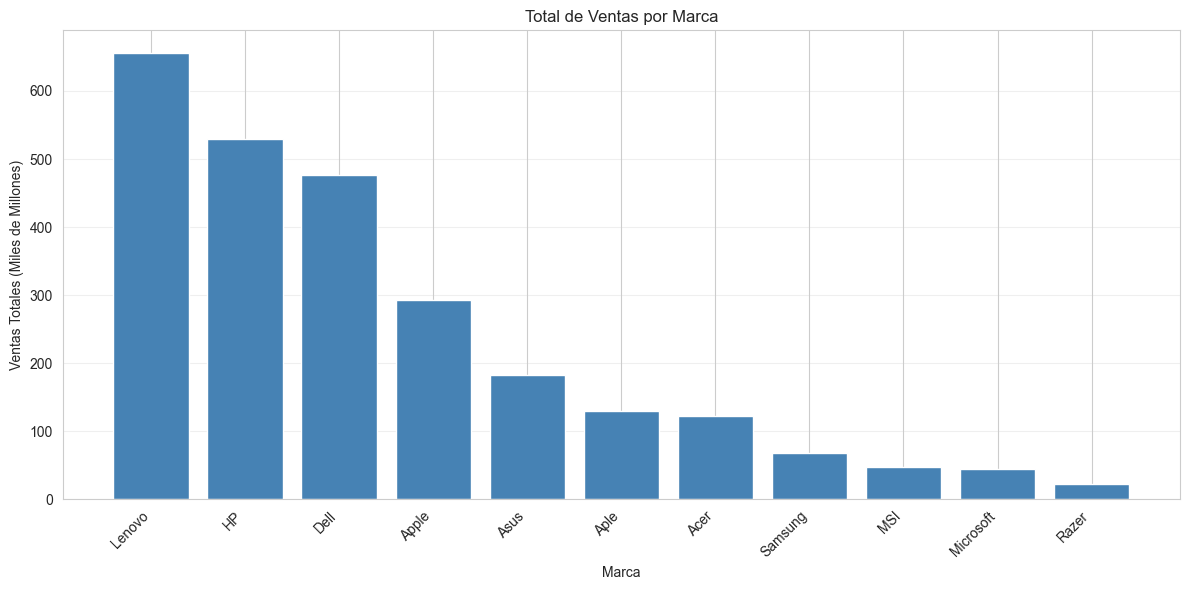

In [63]:
# Reporte: Total de ventas por marca
ventas_por_marca = tabla_detalle_facturas.merge(
    tabla_productos[['ProductoID', 'Marca']], 
    on='ProductoID'
).groupby('Marca').agg({
    'Subtotal': 'sum',
    'Cantidad': 'sum'
}).reset_index()

ventas_por_marca = ventas_por_marca.sort_values('Subtotal', ascending=False)
ventas_por_marca.columns = ['Marca', 'TotalVentas', 'UnidadesVendidas']

print("TOTAL DE VENTAS POR MARCA")
print("=" * 80)
print(ventas_por_marca.to_string(index=False))
print("=" * 80)

# Visualización
plt.figure(figsize=(12, 6))
plt.bar(ventas_por_marca['Marca'], ventas_por_marca['TotalVentas'] / 1e9, color='steelblue')
plt.xlabel('Marca')
plt.ylabel('Ventas Totales (Miles de Millones)')
plt.title('Total de Ventas por Marca')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Top 10 Productos Más Vendidos

TOP 10 PRODUCTOS MÁS VENDIDOS
                  ProductoCompleto  Cantidad     Subtotal
              HP Spectre x360 (HP)     41350 215020000000
Lenovo ThinkPad X1 Carbon (Lenovo)     32724 222523200000
      Lenovo Legion 5 Pro (Lenovo)     32033 230637600000
           Lenovo Yoga 7i (Lenovo)     28605 125862000000
                   HP Omen 16 (HP)     27781 166686000000
         Lenovo IdeaPad 5 (Lenovo)     27551  77142800000
         Dell Latitude 7420 (Dell)     24910 139496000000
                Dell XPS 13 (Dell)     24812 119097600000
               HP Pavilion 15 (HP)     22488  78708000000
         Dell Alienware m15 (Dell)     19939 159512000000


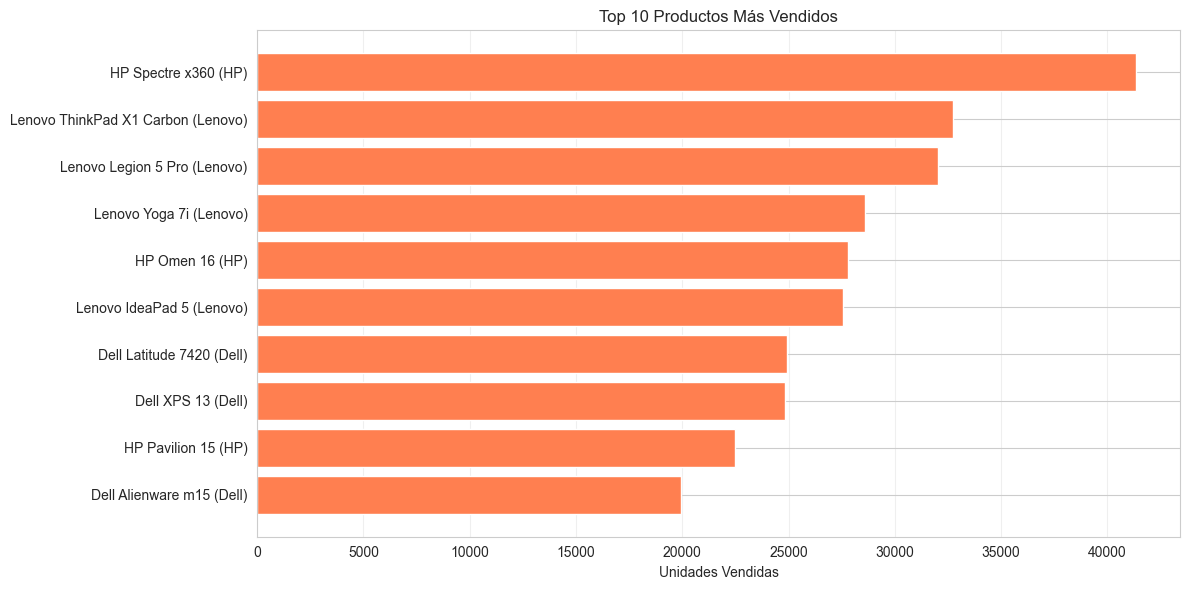

In [64]:
# Reporte: Top 10 productos más vendidos
top_productos = tabla_detalle_facturas.merge(
    tabla_productos[['ProductoID', 'NombreProducto', 'Marca']], 
    on='ProductoID'
).groupby(['NombreProducto', 'Marca']).agg({
    'Cantidad': 'sum',
    'Subtotal': 'sum'
}).reset_index()

top_productos = top_productos.sort_values('Cantidad', ascending=False).head(10)
top_productos['ProductoCompleto'] = top_productos['NombreProducto'] + ' (' + top_productos['Marca'] + ')'

print("TOP 10 PRODUCTOS MÁS VENDIDOS")
print("=" * 80)
print(top_productos[['ProductoCompleto', 'Cantidad', 'Subtotal']].to_string(index=False))
print("=" * 80)

# Visualización
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_productos)), top_productos['Cantidad'], color='coral')
plt.yticks(range(len(top_productos)), top_productos['ProductoCompleto'])
plt.xlabel('Unidades Vendidas')
plt.title('Top 10 Productos Más Vendidos')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Exportación del Modelo a Excel

Exportamos todas las tablas a un archivo Excel con hojas separadas para su importación en Power BI.

In [65]:
# Preparar tablas para exportación - mantener fechas como datetime para Power BI
tabla_facturas_export = tabla_facturas.copy()

# No convertir fechas a string, mantener como datetime (Power BI las detectará automáticamente)
# Los NaT se mantendrán como NaT, que Power BI maneja como valores nulos en fechas

# Para Calendario, mantener Date como datetime (ya lo es)
# No hacer strftime

# Exportar todas las tablas a Excel
archivo_excel = 'modeloVentas.xlsx'

with pd.ExcelWriter(archivo_excel, engine='openpyxl') as writer:
    tabla_facturas_export.to_excel(writer, sheet_name='Facturas', index=False)
    tabla_detalle_facturas.to_excel(writer, sheet_name='DetalleFacturas', index=False)
    tabla_productos.to_excel(writer, sheet_name='Productos', index=False)
    tabla_clientes.to_excel(writer, sheet_name='Clientes', index=False)
    tabla_sucursales.to_excel(writer, sheet_name='Sucursales', index=False)
    tabla_ciudades.to_excel(writer, sheet_name='Ciudades', index=False)
    tabla_vendedores.to_excel(writer, sheet_name='Vendedores', index=False)
    tabla_calendario.to_excel(writer, sheet_name='Calendario', index=False)

print("=" * 80)
print(f"✅ Modelo exportado exitosamente a: {archivo_excel}")
print("=" * 80)
print("\nResumen de tablas exportadas:")
print(f"  • Facturas: {len(tabla_facturas)} registros")
print(f"  • DetalleFacturas: {len(tabla_detalle_facturas)} registros")
print(f"  • Productos: {len(tabla_productos)} registros")
print(f"  • Clientes: {len(tabla_clientes)} registros")
print(f"  • Sucursales: {len(tabla_sucursales)} registros")
print(f"  • Ciudades: {len(tabla_ciudades)} registros")
print(f"  • Vendedores: {len(tabla_vendedores)} registros")
print(f"  • Calendario: {len(tabla_calendario)} fechas")
print("=" * 80)

✅ Modelo exportado exitosamente a: modeloVentas.xlsx

Resumen de tablas exportadas:
  • Facturas: 30000 registros
  • DetalleFacturas: 60059 registros
  • Productos: 44 registros
  • Clientes: 17453 registros
  • Sucursales: 6 registros
  • Ciudades: 4 registros
  • Vendedores: 30 registros
  • Calendario: 4018 fechas


## 8. Implementación Opcional con SQLite

Creamos una base de datos SQLite con las tablas y relaciones definidas para persistencia opcional.

In [71]:
# Crear base de datos SQLite
db_file = 'modeloVentas.db'
conn = sqlite3.connect(db_file)

# Crear tablas con restricciones de integridad
conn.execute('''
CREATE TABLE IF NOT EXISTS Ciudades (
    CiudadID INTEGER PRIMARY KEY,
    NombreCiudad TEXT NOT NULL UNIQUE
)
''')

conn.execute('''
CREATE TABLE IF NOT EXISTS Sucursales (
    SucursalID INTEGER PRIMARY KEY,
    NombreSucursal TEXT NOT NULL,
    CiudadID INTEGER NOT NULL,
    FOREIGN KEY (CiudadID) REFERENCES Ciudades(CiudadID)
)
''')

conn.execute('''
CREATE TABLE IF NOT EXISTS Vendedores (
    VendedorID INTEGER PRIMARY KEY,
    NombreVendedor TEXT NOT NULL
)
''')

conn.execute('''
CREATE TABLE IF NOT EXISTS Clientes (
    ClienteID INTEGER PRIMARY KEY,
    NombreCliente TEXT NOT NULL,
    Genero TEXT,
    Edad INTEGER,
    Telefono TEXT,
    Email TEXT,
    Direccion TEXT
)
''')

conn.execute('''
CREATE TABLE IF NOT EXISTS Productos (
    ProductoID INTEGER PRIMARY KEY,
    NombreProducto TEXT NOT NULL,
    Marca TEXT NOT NULL,
    PrecioUnitario REAL NOT NULL
)
''')

conn.execute('''
CREATE TABLE IF NOT EXISTS Facturas (
    FacturaID INTEGER PRIMARY KEY,
    Fecha TEXT,
    Año INTEGER,
    Trimestre TEXT,
    Mes TEXT,
    Dia INTEGER,
    HoraVenta TEXT,
    SucursalID INTEGER NOT NULL,
    ClienteID INTEGER NOT NULL,
    VendedorID INTEGER NOT NULL,
    MetodoPago TEXT,
    TotalVenta REAL NOT NULL,
    FOREIGN KEY (SucursalID) REFERENCES Sucursales(SucursalID),
    FOREIGN KEY (ClienteID) REFERENCES Clientes(ClienteID),
    FOREIGN KEY (VendedorID) REFERENCES Vendedores(VendedorID)
)
''')

conn.execute('''
CREATE TABLE IF NOT EXISTS DetalleFacturas (
    DetalleID INTEGER PRIMARY KEY,
    FacturaID INTEGER NOT NULL,
    ProductoID INTEGER NOT NULL,
    Cantidad INTEGER NOT NULL,
    Descuento REAL,
    Subtotal REAL NOT NULL,
    FOREIGN KEY (FacturaID) REFERENCES Facturas(FacturaID),
    FOREIGN KEY (ProductoID) REFERENCES Productos(ProductoID)
)
''')

# Insertar datos en las tablas
tabla_ciudades.to_sql('Ciudades', conn, if_exists='replace', index=False)
tabla_sucursales.to_sql('Sucursales', conn, if_exists='replace', index=False)
tabla_vendedores.to_sql('Vendedores', conn, if_exists='replace', index=False)
tabla_clientes.to_sql('Clientes', conn, if_exists='replace', index=False)
tabla_productos.to_sql('Productos', conn, if_exists='replace', index=False)
tabla_facturas.to_sql('Facturas', conn, if_exists='replace', index=False)
tabla_detalle_facturas.to_sql('DetalleFacturas', conn, if_exists='replace', index=False)

conn.commit()
conn.close()

print("=" * 80)
print(f"✅ Base de datos SQLite creada: {db_file}")
print("=" * 80)

✅ Base de datos SQLite creada: modeloVentas.db


## 9. Diagrama Entidad-Relación del Modelo

### Descripción del Modelo Relacional

**Tablas Dimensionales:**

1. **Ciudades**
   - CiudadID (PK)
   - NombreCiudad

2. **Sucursales**
   - SucursalID (PK)
   - NombreSucursal
   - CiudadID (FK → Ciudades)
   
3. **Vendedores**
   - VendedorID (PK)
   - NombreVendedor

4. **Clientes**
   - ClienteID (PK)
   - NombreCliente
   - Genero
   - Edad
   - Telefono
   - Email
   - Direccion

5. **Productos**
   - ProductoID (PK)
   - NombreProducto
   - Marca
   - PrecioUnitario

6. **Calendario**
   - CalendarioID (PK)
   - Date
   - Año, Trimestre, Mes, MesNum, Día, AñoMes, NombreMes

**Tablas de Hechos:**

7. **Facturas**
   - FacturaID (PK)
   - Fecha
   - Año, Trimestre, Mes, Dia
   - HoraVenta
   - SucursalID (FK → Sucursales)
   - ClienteID (FK → Clientes)
   - VendedorID (FK → Vendedores)
   - CalendarioID (FK → Calendario)
   - MetodoPago
   - TotalVenta

8. **DetalleFacturas**
   - DetalleID (PK)
   - FacturaID (FK → Facturas)
   - ProductoID (FK → Productos)
   - Cantidad
   - Descuento
   - Subtotal

### Relaciones y Cardinalidad

```
Ciudades (1) ──────< (N) Sucursales
Sucursales (1) ────< (N) Facturas
Vendedores (1) ────< (N) Facturas
Clientes (1) ──────< (N) Facturas
Calendario (1) ────< (N) Facturas
Facturas (1) ──────< (N) DetalleFacturas
Productos (1) ─────< (N) DetalleFacturas
```

**Cardinalidades:**
- Una ciudad puede tener muchas sucursales (1:N)
- Una sucursal puede tener muchas facturas (1:N)
- Un vendedor puede tener muchas facturas (1:N)
- Un cliente puede tener muchas facturas (1:N)
- Una fecha puede tener muchas facturas (1:N)
- Una factura puede tener muchos detalles (1:N)
- Un producto puede aparecer en muchos detalles (1:N)

### Diagrama Visual

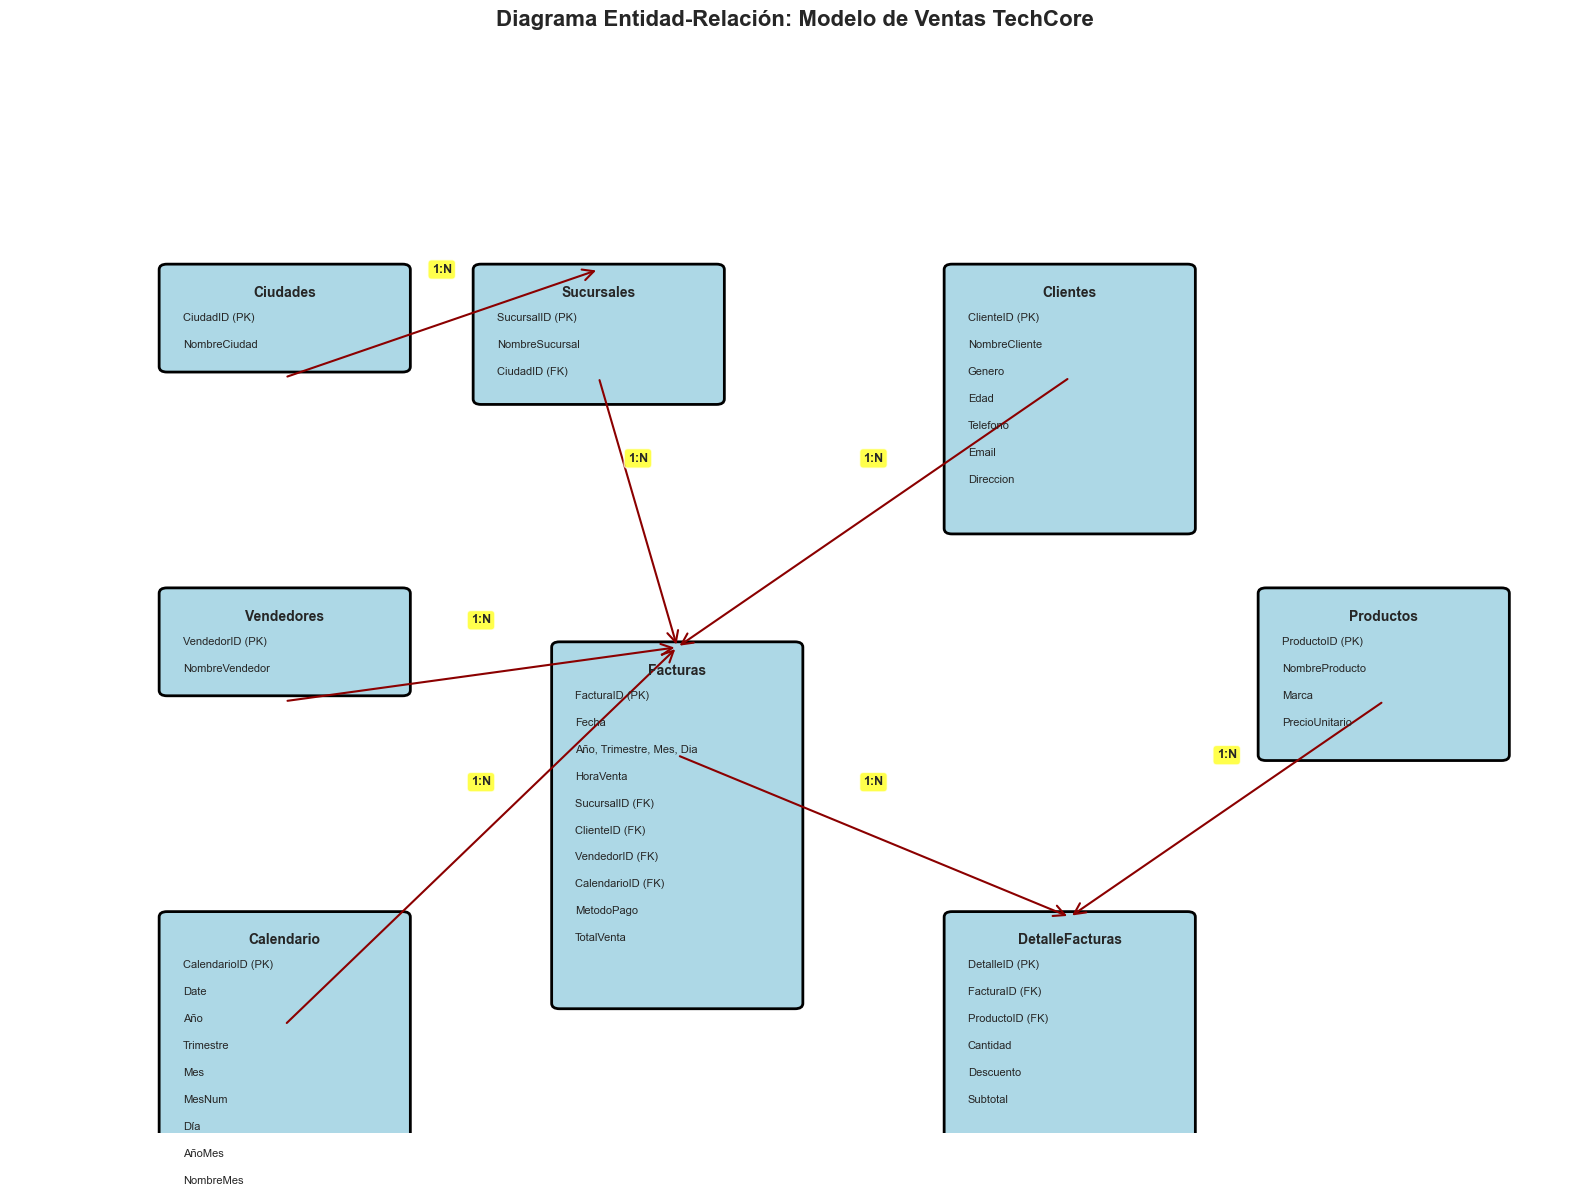

✅ Diagrama ER generado


In [70]:
# Crear diagrama visual del modelo
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Definir posiciones de las tablas
tablas = {
    'Ciudades': {'pos': (1, 8), 'attrs': ['CiudadID (PK)', 'NombreCiudad']},
    'Sucursales': {'pos': (3, 8), 'attrs': ['SucursalID (PK)', 'NombreSucursal', 'CiudadID (FK)']},
    'Vendedores': {'pos': (1, 5), 'attrs': ['VendedorID (PK)', 'NombreVendedor']},
    'Clientes': {'pos': (6, 8), 'attrs': ['ClienteID (PK)', 'NombreCliente', 'Genero', 'Edad', 'Telefono', 'Email', 'Direccion']},
    'Productos': {'pos': (8, 5), 'attrs': ['ProductoID (PK)', 'NombreProducto', 'Marca', 'PrecioUnitario']},
    'Calendario': {'pos': (1, 2), 'attrs': ['CalendarioID (PK)', 'Date', 'Año', 'Trimestre', 'Mes', 'MesNum', 'Día', 'AñoMes', 'NombreMes']},
    'Facturas': {'pos': (3.5, 4.5), 'attrs': ['FacturaID (PK)', 'Fecha', 'Año, Trimestre, Mes, Dia', 'HoraVenta', 'SucursalID (FK)', 'ClienteID (FK)', 'VendedorID (FK)', 'CalendarioID (FK)', 'MetodoPago', 'TotalVenta']},
    'DetalleFacturas': {'pos': (6, 2), 'attrs': ['DetalleID (PK)', 'FacturaID (FK)', 'ProductoID (FK)', 'Cantidad', 'Descuento', 'Subtotal']}
}

# Dibujar tablas
for tabla, info in tablas.items():
    x, y = info['pos']
    attrs = info['attrs']
    height = len(attrs) * 0.3 + 0.3
    
    # Cuadro de la tabla
    rect = FancyBboxPatch((x, y - height), 1.5, height, 
                           boxstyle="round,pad=0.05", 
                           edgecolor='black', facecolor='lightblue', linewidth=2)
    ax.add_patch(rect)
    
    # Nombre de la tabla
    ax.text(x + 0.75, y - 0.15, tabla, ha='center', va='top', 
            fontweight='bold', fontsize=10)
    
    # Atributos
    for i, attr in enumerate(attrs):
        ax.text(x + 0.1, y - 0.4 - i * 0.25, attr, ha='left', va='top', fontsize=8)

# Dibujar relaciones
relaciones = [
    {'from': 'Ciudades', 'to': 'Sucursales', 'label': '1:N'},
    {'from': 'Sucursales', 'to': 'Facturas', 'label': '1:N'},
    {'from': 'Vendedores', 'to': 'Facturas', 'label': '1:N'},
    {'from': 'Clientes', 'to': 'Facturas', 'label': '1:N'},
    {'from': 'Calendario', 'to': 'Facturas', 'label': '1:N'},
    {'from': 'Facturas', 'to': 'DetalleFacturas', 'label': '1:N'},
    {'from': 'Productos', 'to': 'DetalleFacturas', 'label': '1:N'}
]

for rel in relaciones:
    from_pos = tablas[rel['from']]['pos']
    to_pos = tablas[rel['to']]['pos']
    
    arrow = FancyArrowPatch((from_pos[0] + 0.75, from_pos[1] - 1), 
                           (to_pos[0] + 0.75, to_pos[1]),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=1.5, color='darkred')
    ax.add_patch(arrow)
    
    # Etiqueta de cardinalidad
    mid_x = (from_pos[0] + to_pos[0]) / 2 + 0.75
    mid_y = (from_pos[1] + to_pos[1]) / 2
    ax.text(mid_x, mid_y, rel['label'], ha='center', va='center', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7), 
            fontsize=9, fontweight='bold')

plt.title('Diagrama Entidad-Relación: Modelo de Ventas TechCore', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("=" * 80)
print("✅ Diagrama ER generado")
print("=" * 80)

## 10. Resumen del Modelo Relacional

### Estadísticas Finales

In [68]:
print("=" * 80)
print("RESUMEN DEL MODELO RELACIONAL - TECHCORE")
print("=" * 80)
print("\n📊 ESTADÍSTICAS DEL MODELO:")
print(f"\n  Tablas Dimensionales:")
print(f"    • Ciudades: {len(tabla_ciudades):,} registros")
print(f"    • Sucursales: {len(tabla_sucursales):,} registros")
print(f"    • Vendedores: {len(tabla_vendedores):,} registros")
print(f"    • Clientes: {len(tabla_clientes):,} registros")
print(f"    • Productos: {len(tabla_productos):,} registros")
print(f"    • Calendario: {len(tabla_calendario):,} fechas")

print(f"\n  Tablas de Hechos:")
print(f"    • Facturas: {len(tabla_facturas):,} registros")
print(f"    • DetalleFacturas: {len(tabla_detalle_facturas):,} registros")

print(f"\n📈 MÉTRICAS DE NEGOCIO:")
print(f"    • Total de ventas: ${tabla_facturas['TotalVenta'].sum():,.2f}")
print(f"    • Promedio por factura: ${tabla_facturas['TotalVenta'].mean():,.2f}")
print(f"    • Productos por factura (promedio): {len(tabla_detalle_facturas) / len(tabla_facturas):.2f}")
print(f"    • Unidades totales vendidas: {tabla_detalle_facturas['Cantidad'].sum():,}")

print(f"\n✅ ARCHIVOS GENERADOS:")
print(f"    • modeloVentas.xlsx (Excel con 8 hojas)")
print(f"    • modeloVentas.db (Base de datos SQLite)")

print(f"\n🔗 INTEGRIDAD REFERENCIAL:")
print(f"    • Todas las claves foráneas validadas correctamente")
print(f"    • Sin registros huérfanos detectados")

print("\n" + "=" * 80)
print("✅ AVANCE 2 COMPLETADO EXITOSAMENTE")
print("=" * 80)
print("\nPróximos pasos:")
print("  1. Importar modeloVentas.xlsx en Power BI")
print("  2. Configurar relaciones en el modelo de Power BI")
print("  3. Crear visualizaciones para el dashboard (Avance 3)")
print("=" * 80)

RESUMEN DEL MODELO RELACIONAL - TECHCORE

📊 ESTADÍSTICAS DEL MODELO:

  Tablas Dimensionales:
    • Ciudades: 4 registros
    • Sucursales: 6 registros
    • Vendedores: 30 registros
    • Clientes: 17,453 registros
    • Productos: 44 registros
    • Calendario: 4,018 fechas

  Tablas de Hechos:
    • Facturas: 30,000 registros
    • DetalleFacturas: 60,059 registros

📈 MÉTRICAS DE NEGOCIO:
    • Total de ventas: $4,564,916,700,000.00
    • Promedio por factura: $152,163,890.00
    • Productos por factura (promedio): 2.00
    • Unidades totales vendidas: 495,597

✅ ARCHIVOS GENERADOS:
    • modeloVentas.xlsx (Excel con 8 hojas)
    • modeloVentas.db (Base de datos SQLite)

🔗 INTEGRIDAD REFERENCIAL:
    • Todas las claves foráneas validadas correctamente
    • Sin registros huérfanos detectados

✅ AVANCE 2 COMPLETADO EXITOSAMENTE

Próximos pasos:
  1. Importar modeloVentas.xlsx en Power BI
  2. Configurar relaciones en el modelo de Power BI
  3. Crear visualizaciones para el dashboard 

## 10.1 Verificación de Relaciones - Unión de Tablas

Para demostrar que las relaciones funcionan correctamente, realizamos uniones (joins) entre las tablas principales y la dimensión Calendario.

In [72]:
# Verificar la relación Facturas ↔ Calendario
print("=" * 80)
print("VERIFICACIÓN DE RELACIÓN: FACTURAS ↔ CALENDARIO")
print("=" * 80)

# Realizar el join entre Facturas y Calendario
facturas_con_calendario = tabla_facturas.merge(
    tabla_calendario[['Date', 'Año', 'Trimestre', 'Mes', 'MesNum', 'Día']],
    left_on='Fecha',
    right_on='Date',
    how='left'
)

print(f"Registros en Facturas: {len(tabla_facturas)}")
print(f"Registros después del join: {len(facturas_con_calendario)}")
print(f"Facturas sin fecha en calendario: {facturas_con_calendario['Date'].isnull().sum()}")

print(f"\nPrimeras 5 facturas con información de calendario:")
facturas_con_calendario[['FacturaID', 'Fecha', 'Año_y', 'Trimestre_y', 'Mes_y', 'TotalVenta']].head()

# Verificar otras relaciones importantes
print(f"\n" + "=" * 80)
print("VERIFICACIÓN DE OTRAS RELACIONES CLAVE")
print("=" * 80)

# Facturas con Sucursales
facturas_con_sucursales = tabla_facturas.merge(
    tabla_sucursales[['SucursalID', 'NombreSucursal']],
    on='SucursalID',
    how='left'
)

print(f"Facturas con sucursales: {len(facturas_con_sucursales)} (debería ser {len(tabla_facturas)})")

# Detalles con Productos
detalles_con_productos = tabla_detalle_facturas.merge(
    tabla_productos[['ProductoID', 'NombreProducto', 'Marca']],
    on='ProductoID',
    how='left'
)

print(f"Detalles con productos: {len(detalles_con_productos)} (debería ser {len(tabla_detalle_facturas)})")

print(f"\n✅ RELACIONES VERIFICADAS: Todas las uniones se realizaron correctamente")
print("=" * 80)

VERIFICACIÓN DE RELACIÓN: FACTURAS ↔ CALENDARIO
Registros en Facturas: 30000
Registros después del join: 30000
Facturas sin fecha en calendario: 0

Primeras 5 facturas con información de calendario:

VERIFICACIÓN DE OTRAS RELACIONES CLAVE
Facturas con sucursales: 30000 (debería ser 30000)
Detalles con productos: 60059 (debería ser 60059)

✅ RELACIONES VERIFICADAS: Todas las uniones se realizaron correctamente
